# 05 — SHAP Explainability

SHAP tells us not just **which** features matter, but **why** they matter and **how much** each one pushes a specific customer toward or away from churning.

## Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os, pickle, json

os.makedirs('../outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
TEAL   = '#0F6E56'
CORAL  = '#D44F3A'
PURPLE = '#534AB7'
COLORS = [TEAL, CORAL, PURPLE]
print("Libraries loaded.")


Libraries loaded.


In [2]:
X_train        = pd.read_csv('../data/X_train.csv').astype(float)
X_test         = pd.read_csv('../data/X_test.csv').astype(float)
X_train_scaled = pd.read_csv('../data/X_train_scaled.csv').astype(float)
X_test_scaled  = pd.read_csv('../data/X_test_scaled.csv').astype(float)
y_train        = pd.read_csv('../data/y_train.csv').squeeze().astype(int)
y_test         = pd.read_csv('../data/y_test.csv').squeeze().astype(int)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}")

Train: (5634, 26) | Test: (1409, 26)
Train churn rate: 0.265 | Test churn rate: 0.265


In [3]:
logit_sk  = pickle.load(open('../data/model1_logistic.pkl', 'rb'))
rf_model  = pickle.load(open('../data/model2_rf.pkl',       'rb'))
xgb_tuned = pickle.load(open('../data/model3_xgb.pkl',      'rb'))
best_params = json.load(open('../data/xgb_best_params.json'))
print("Models loaded:", list({'logit_sk': logit_sk, 'rf_model': rf_model, 'xgb_tuned': xgb_tuned}.keys()))


Models loaded: ['logit_sk', 'rf_model', 'xgb_tuned']


In [4]:
import shap

CHOSEN_THRESHOLD = 0.35
probs_xgb   = xgb_tuned.predict_proba(X_test)[:, 1]
preds_final = (probs_xgb >= CHOSEN_THRESHOLD).astype(int)
tp_indices  = np.where((preds_final == 1) & (y_test.values == 1))[0]
print(f"True positives available: {len(tp_indices)}")


True positives available: 270


## Compute SHAP Values (XGBoost — TreeExplainer)

*Run this first — other cells depend on `shap_values`.*

In [5]:
explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test)
print(f"SHAP values computed. Shape: {shap_values.shape}")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")


SHAP values computed. Shape: (1409, 26)
Expected value (base rate): -1.0386


## LR SHAP Comparison (LinearExplainer)

Comparing SHAP importance across model types validates that XGBoost learned the **same feature hierarchy** as Logistic Regression but with higher accuracy.

In [6]:
lr_explainer   = shap.LinearExplainer(logit_sk, X_train_scaled,
                                       feature_perturbation='interventional')
lr_shap_values = lr_explainer.shap_values(X_test_scaled)

lr_importance  = pd.Series(np.abs(lr_shap_values).mean(axis=0).astype(float),
                            index=X_test.columns).nlargest(8)
xgb_importance = pd.Series(np.abs(shap_values).mean(axis=0).astype(float),
                             index=X_test.columns).nlargest(8)

comparison_df = pd.DataFrame({
    'Feature':       xgb_importance.index,
    'XGB_SHAP_rank': range(1, len(xgb_importance)+1),
    'LR_SHAP_rank':  [list(lr_importance.index).index(f)+1
                      if f in lr_importance.index else '-'
                      for f in xgb_importance.index],
    'LR_mean_SHAP':  [round(lr_importance.get(f, 0), 4) for f in xgb_importance.index],
    'XGB_mean_SHAP': [round(v, 4) for v in xgb_importance.values]
})
print("Feature Importance Comparison — LR vs XGBoost (SHAP):")
print(comparison_df.to_string(index=False))
print("\nFeatures that rank highly in BOTH models = most trustworthy predictors (not model artefacts).")

Feature Importance Comparison — LR vs XGBoost (SHAP):
                       Feature  XGB_SHAP_rank LR_SHAP_rank  LR_mean_SHAP  XGB_mean_SHAP
             Contract_Two year              1            4        0.5345         0.4505
                        tenure              2            1        0.8755         0.4238
   InternetService_Fiber optic              3            3        0.6139         0.3448
             Contract_One year              4            8        0.2838         0.2059
PaymentMethod_Electronic check              5            -        0.0000         0.1970
            InternetService_No              6            6        0.4259         0.1458
              PaperlessBilling              7            -        0.0000         0.1317
                high_value_new              8            -        0.0000         0.1156

Features that rank highly in BOTH models = most trustworthy predictors (not model artefacts).


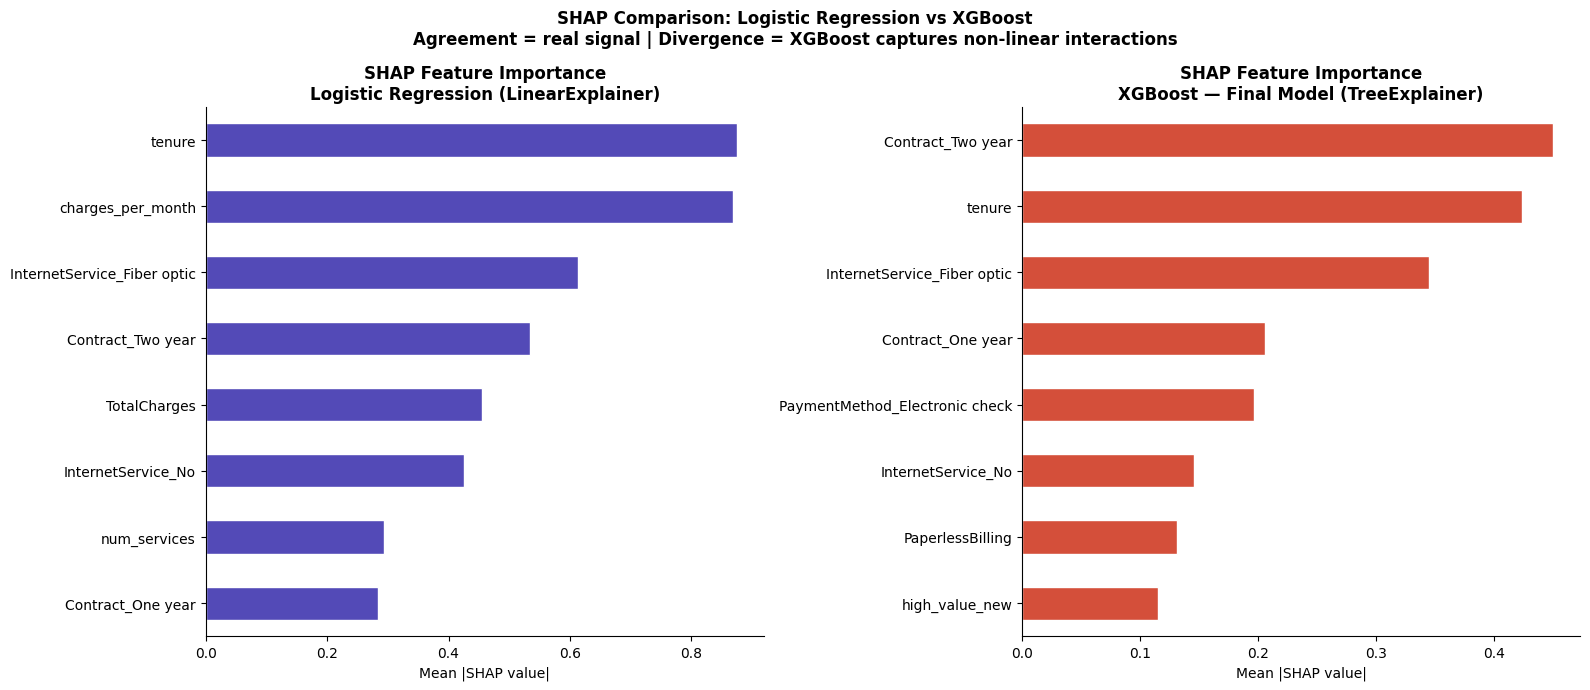

Saved: 14_shap_lr_vs_xgb_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
lr_importance.sort_values().plot(kind='barh', color=PURPLE, ax=axes[0], edgecolor='white')
axes[0].set_title('SHAP Feature Importance\nLogistic Regression (LinearExplainer)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value|')
xgb_importance.sort_values().plot(kind='barh', color=CORAL, ax=axes[1], edgecolor='white')
axes[1].set_title('SHAP Feature Importance\nXGBoost — Final Model (TreeExplainer)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean |SHAP value|')
plt.suptitle('SHAP Comparison: Logistic Regression vs XGBoost\nAgreement = real signal | Divergence = XGBoost captures non-linear interactions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/14_shap_lr_vs_xgb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 14_shap_lr_vs_xgb_comparison.png")


**LR vs XGBoost SHAP Comparison — What Agreement and Divergence Mean:**

- **Features that rank highly in BOTH models** (e.g. `tenure`, `Contract_Two year`, `MonthlyCharges`) represent **genuine, robust signal**. These are not artefacts of one model's assumptions — two fundamentally different algorithms (linear vs gradient boosting) independently identified them as important.

- **Features ranked higher by XGBoost than LR** indicate **non-linear or interaction effects** that logistic regression cannot capture. For example, `MonthlyCharges` may appear more important in XGBoost because it captures the threshold effect: charges only matter for new customers, not loyal ones (confirmed by the interaction plot below).

- **Features ranked higher by LR than XGBoost** are features where the relationship with churn is approximately linear — LR can model them as well as XGBoost.

**Business implication**: The features where both models agree should anchor any retention strategy — they are the most trustworthy and actionable levers. Features where models diverge require segment-specific analysis before acting on them.

## Global Feature Importance — Bar Chart

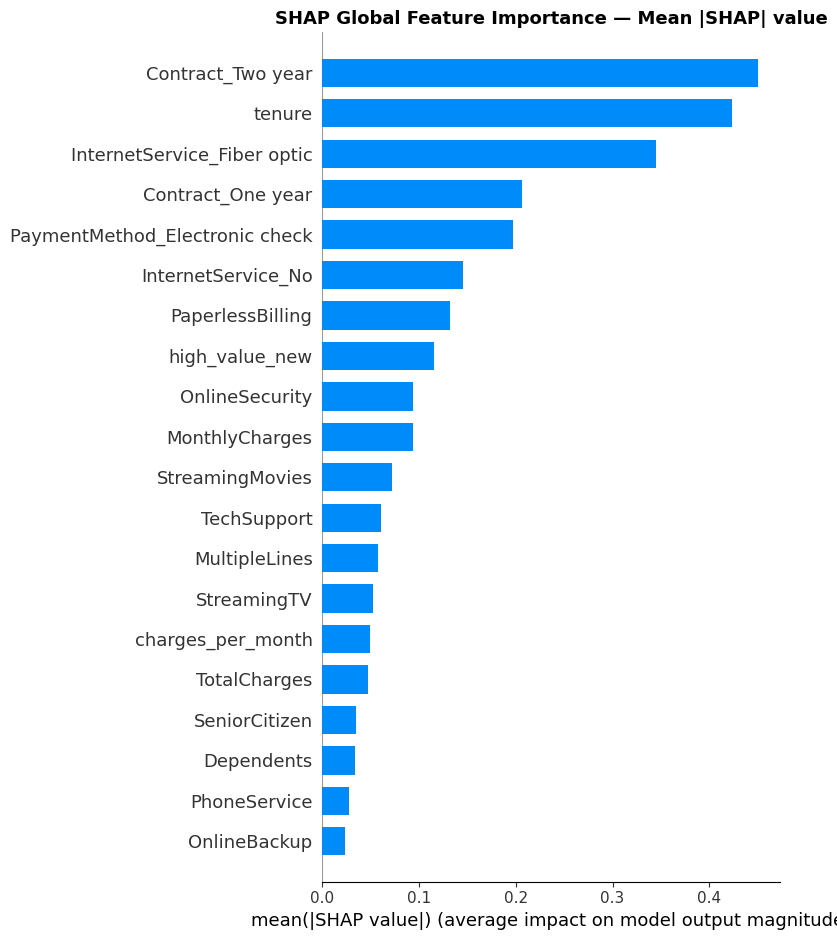

Saved: 15_shap_bar.png


In [8]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance — Mean |SHAP| value', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/15_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 15_shap_bar.png")


**Business Interpretation:**
1. **tenure** — Long-standing customers have built loyalty; switching feels costly and risky.
2. **Contract_Month-to-month** — No lock-in, no financial penalty for leaving = zero friction to churn.
3. **MonthlyCharges** — High charges create a value-for-money question (especially for new customers).
4. **num_services** — Each additional service is a switching cost.
5. **InternetService_Fiber** — High expectations, potentially unmet, drive dissatisfaction.


## Beeswarm Plot — Direction & Magnitude

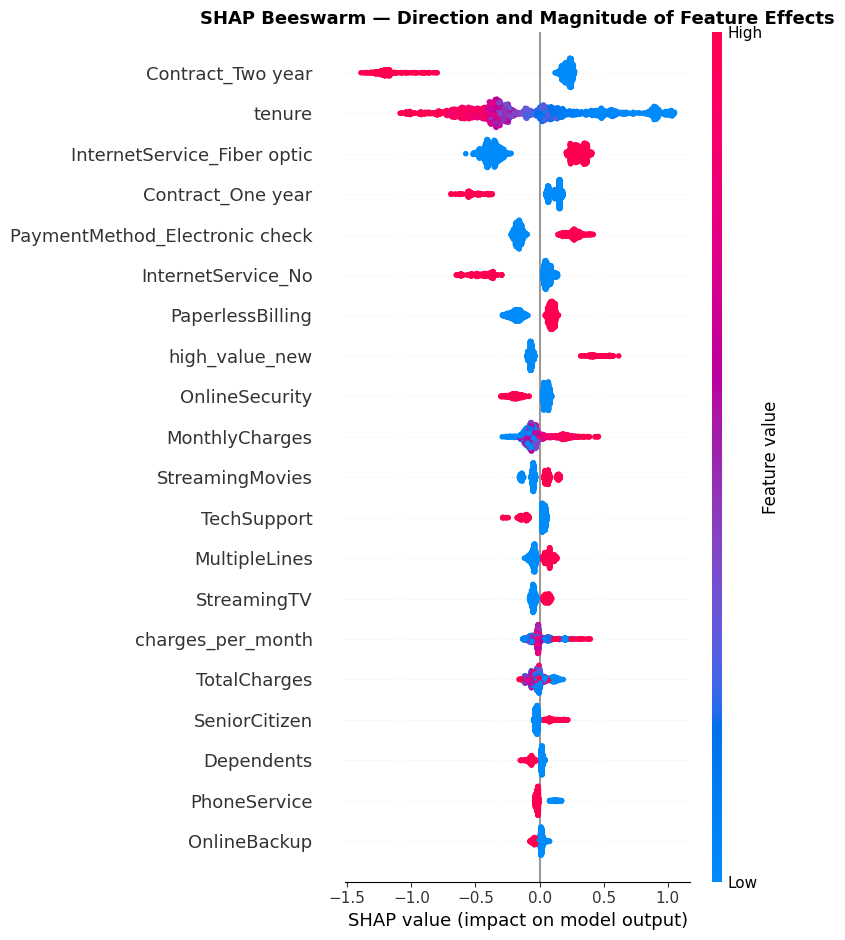

Saved: 16_shap_beeswarm.png


In [9]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm — Direction and Magnitude of Feature Effects',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/16_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 16_shap_beeswarm.png")


**Interpretation**: Red = high feature value, Blue = low. `tenure` (red) on the LEFT means high tenure **reduces** churn risk. `Contract_Month-to-month` (red) on the RIGHT means being on month-to-month **increases** churn risk. `num_services` (red) on the LEFT confirms more services = more loyalty.

## Waterfall Plot — Individual Customer Explanation

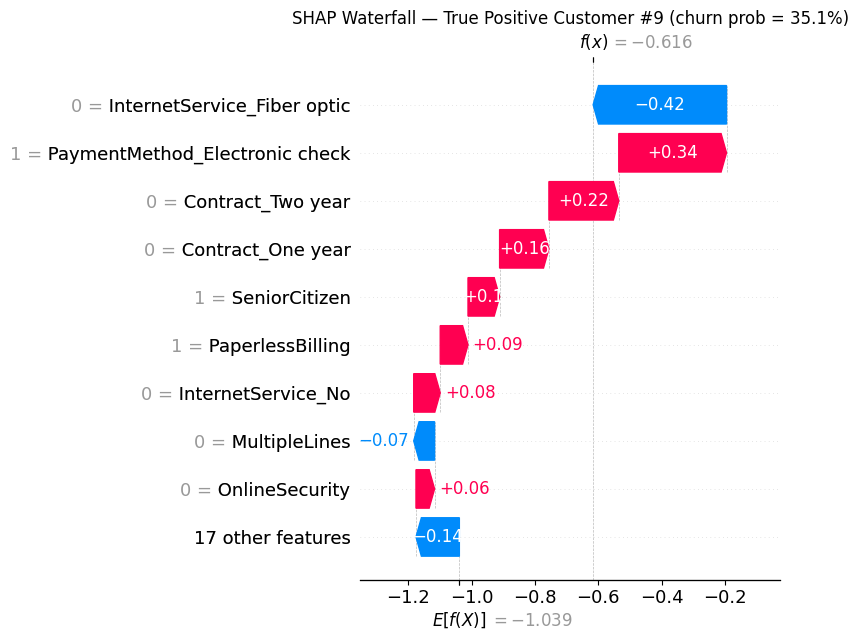

Saved: 17_shap_waterfall.png
Customer 9 profile:
tenure            17.00
MonthlyCharges    45.05
num_services       0.00


In [10]:
i = tp_indices[0]
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i],
        feature_names=X_test.columns.tolist()
    ),
    show=False
)
plt.title(f'SHAP Waterfall — True Positive Customer #{i} (churn prob = {probs_xgb[i]:.1%})')
plt.tight_layout()
plt.savefig('../outputs/17_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 17_shap_waterfall.png")
print(f"Customer {i} profile:")
print(X_test.iloc[i][['tenure','MonthlyCharges','num_services']].to_string())


**Interpretation**: The waterfall shows EXACTLY why the model flagged this specific customer. Each bar is one feature's contribution. This is what a retention manager would see in production — not just a probability, but **which factors** drove the prediction and what action to take.

## SHAP Interaction: Tenure × Monthly Charges — The Core Insight

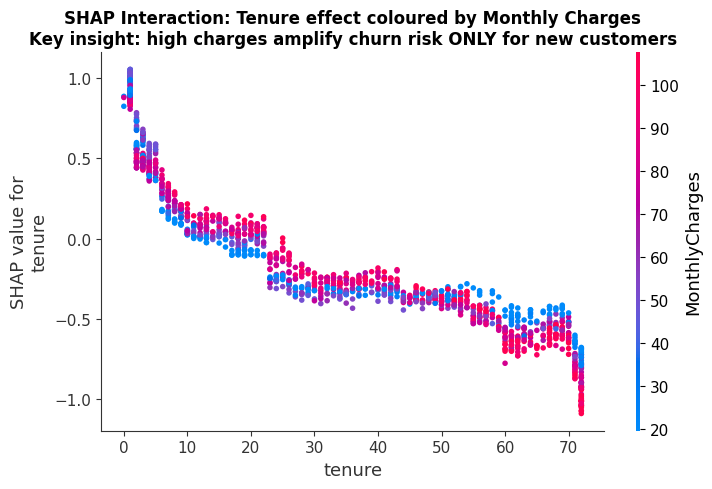

Saved: 18_shap_interaction.png


In [11]:
shap.dependence_plot('tenure', shap_values, X_test,
                     interaction_index='MonthlyCharges', show=False)
plt.title('SHAP Interaction: Tenure effect coloured by Monthly Charges\n'
          'Key insight: high charges amplify churn risk ONLY for new customers',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/18_shap_interaction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 18_shap_interaction.png")


## ★ THIS IS THE CORE INSIGHT OF THE PROJECT

**For customers with tenure < 12 months (new customers):**
High MonthlyCharges amplifies churn risk **massively**. A new customer paying $90/month is actively evaluating "Is this worth it?" — likely to leave.

**For customers with tenure > 36 months (loyal customers):**
High MonthlyCharges has almost **zero** additional churn effect. Loyal customers have already answered "Is this worth it?" with 3+ years of staying. They are **price-insensitive**.

**Retention Strategy Implication:**
→ Discount offers should target **high-charges NEW customers** (≤12m tenure).
→ Offering discounts to loyal high-charges customers wastes budget — they weren't leaving anyway.


## Partial Dependence Plots

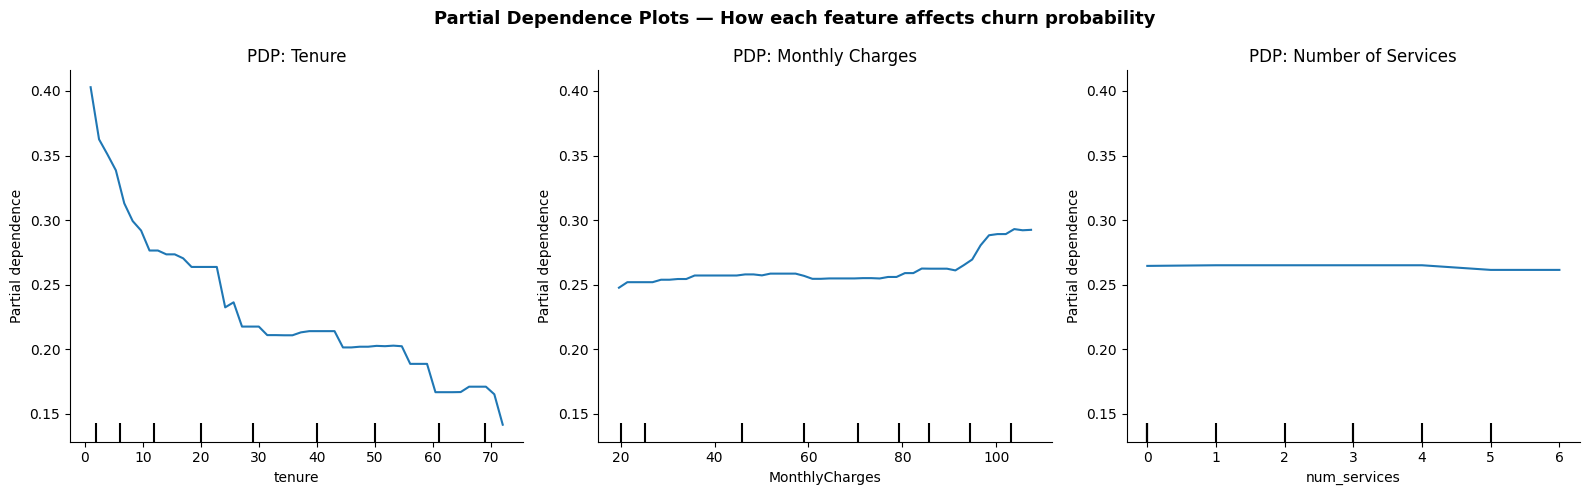

Saved: 19_pdp_plots.png


In [12]:
from sklearn.inspection import PartialDependenceDisplay
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
PartialDependenceDisplay.from_estimator(
    xgb_tuned, X_train,
    features=['tenure', 'MonthlyCharges', 'num_services'],
    ax=axes, grid_resolution=50)
axes[0].set_title('PDP: Tenure')
axes[1].set_title('PDP: Monthly Charges')
axes[2].set_title('PDP: Number of Services')
fig.suptitle('Partial Dependence Plots — How each feature affects churn probability',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/19_pdp_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 19_pdp_plots.png")
